<a href="https://colab.research.google.com/github/MachineLearning30110/MachineLearning-Models/blob/main/Wine_Dataset_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine

data = load_wine()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [70]:
df.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='object')

In [71]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

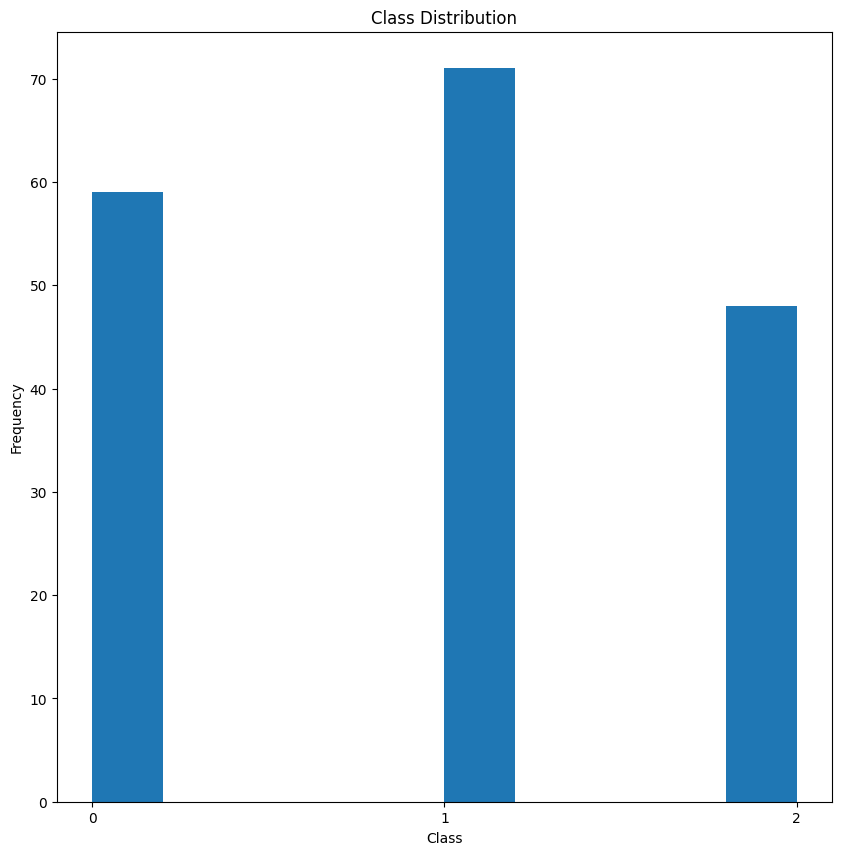

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.hist(df['target'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.xticks(np.unique(df['target']))
plt.show()

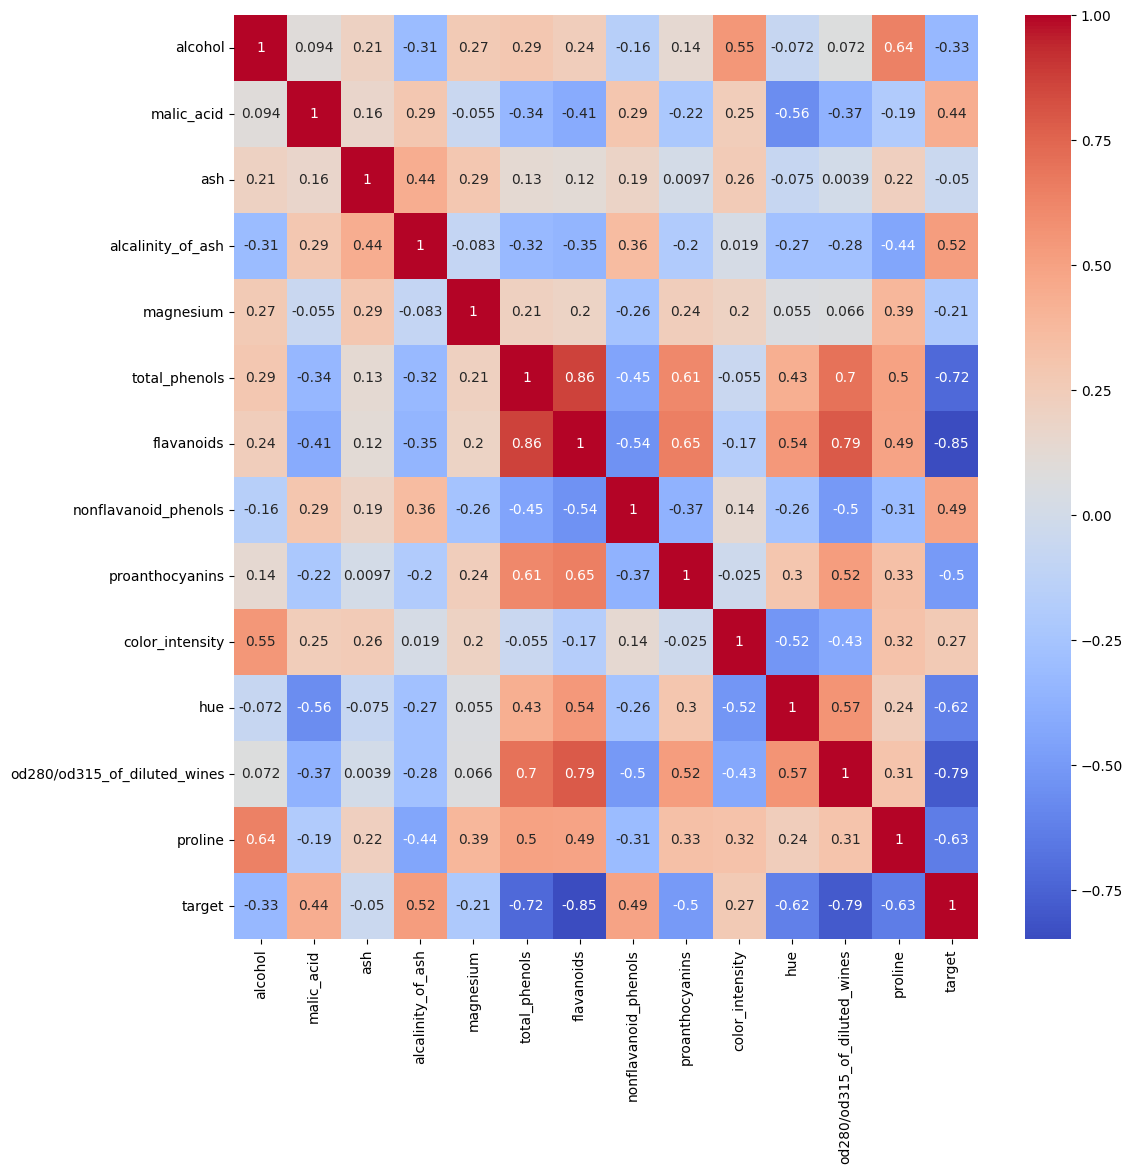

In [74]:
import seaborn as sns

corr = df.corr()
plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [75]:
df["phenols_ratio"] = df["total_phenols"] / df["flavanoids"]
df["ash_magnesium_ratio"] = df["ash"] / df["magnesium"]
df["alcohol_acid_balance"] = df["alcohol"] / df["malic_acid"]

In [76]:
df = df.drop(["total_phenols", "flavanoids", "ash", "magnesium", "alcohol", "malic_acid"], axis=1, errors="ignore")
df.head()

,alcalinity_of_ash,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,phenols_ratio,ash_magnesium_ratio,alcohol_acid_balance
0,15.6,0.28,2.29,5.64,1.04,3.92,1065.0,0,0.915033,0.019134,8.321637
1,11.2,0.26,1.28,4.38,1.05,3.40,1050.0,0,0.960145,0.021400,7.415730
2,18.6,0.30,2.81,5.68,1.03,3.17,1185.0,0,0.864198,0.026436,5.576271
3,16.8,0.24,2.18,7.80,0.86,3.45,1480.0,0,1.103152,0.022124,7.369231
4,21.0,0.39,1.82,4.32,1.04,2.93,735.0,0,1.040892,0.024322,5.111969


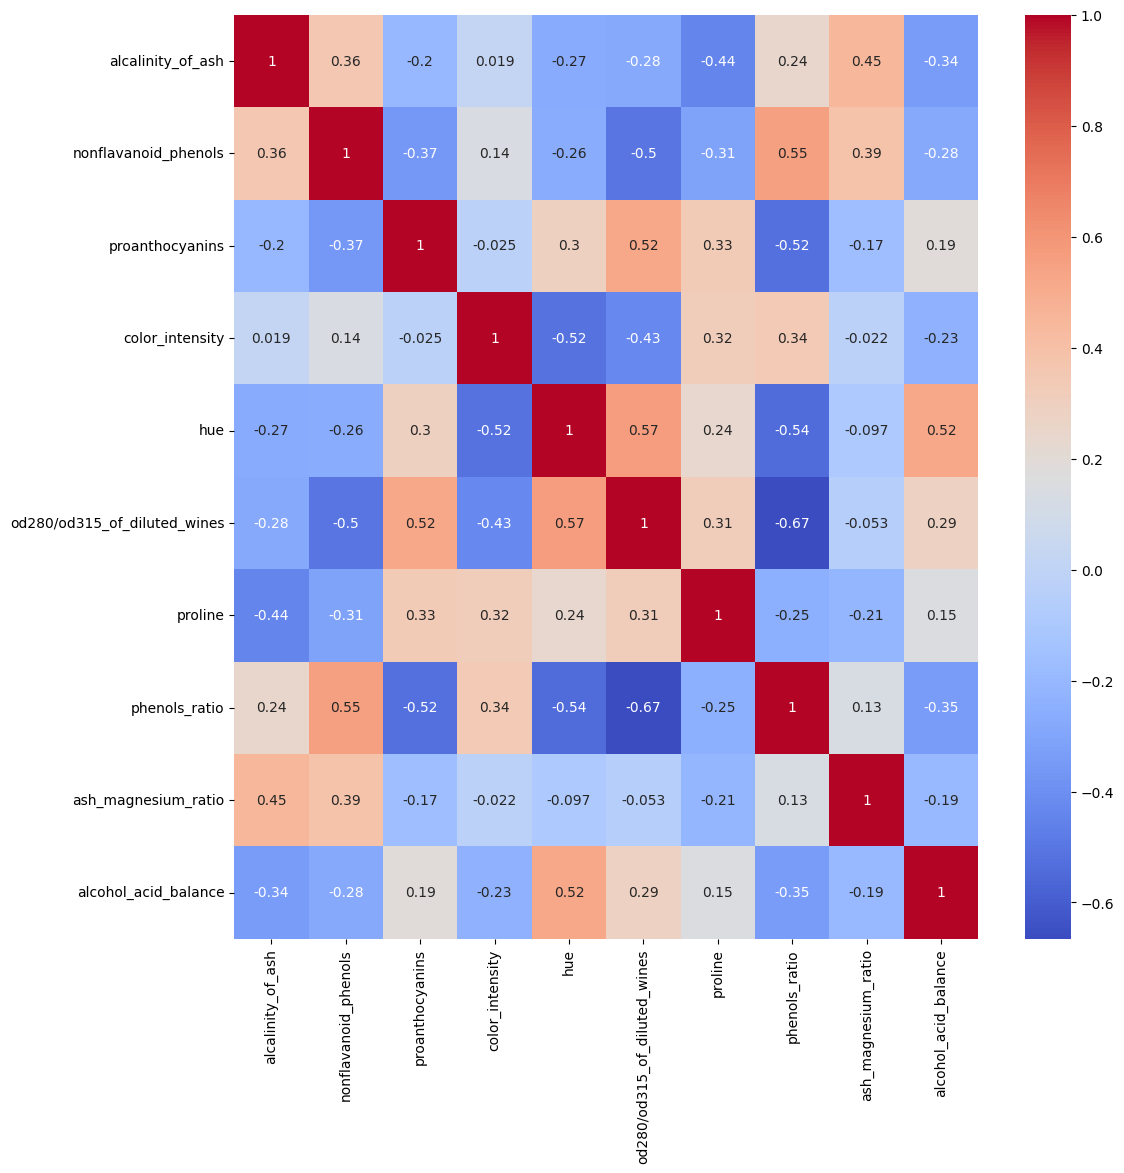

In [77]:
plt.figure(figsize=(12, 12))
sns.heatmap(df.drop('target',axis=1).corr(), annot=True, cmap='coolwarm')
plt.show()

In [78]:
X = df.drop('target', axis=1)
y = df['target']

In [79]:
import os
from google.colab import drive

drive.mount('/content/drive')

TARGET_COL = "target"
MODEL_DIR = "/content/drive/MyDrive/Colab Notebooks"
MODEL_PATH = os.path.join(MODEL_DIR, "wine.pkl")

os.makedirs(MODEL_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [85]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

num_cols = list(df.drop('target',axis=1).columns)

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
])

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [89]:
import joblib

def saveModel(model, model_path):
    joblib.dump(model, model_path)
    print(f"Saved model to: {model_path}")

In [91]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    return {"accuracy": acc, "f1_weighted": f1}

In [90]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

pipeline.fit(X_train, y_train)

saveModel(pipeline, MODEL_PATH)

Saved model to: /content/drive/MyDrive/Colab Notebooks/wine.pkl


In [92]:
base_metrics = evaluate_model(pipeline, X_test, y_test)
base_metrics

{'accuracy': 1.0, 'f1_weighted': 1.0}

In [93]:
param_grid = {
    "model__n_estimators": [100, 150, 200, 250, 300],
    "model__max_depth": [None, 5, 10, 15, 20]
}
scoring = "f1_weighted"

Multi_Pipeline = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring=scoring,
    n_jobs=-1,
    verbose=1
)

Multi_Pipeline.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['alcalinity_of_ash',
                                                                          'nonflavanoid_phenols',
                                                                          'proanthocyanins',
                                                                          'color_intensity',
                                                                          'hue',
                                                                          'od280/od315_of_diluted_wines',
                                                                          'proline',
                                                                          'phenols_ratio',
                                                                          'ash_magnesium_ratio',
                                                                          'alcohol_acid_balance'])])),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 5, 10, 15, 20],
                         'model__n_estimators': [100, 150, 200, 250, 300]},
             scoring='f1_weighted', verbose=1)

In [96]:
tuned_metrics = evaluate_model(Multi_Pipeline, X_test, y_test)
print("Best params:", Multi_Pipeline.best_params_)
print("Tuned model metrics:", tuned_metrics)

Best params: {'model__max_depth': None, 'model__n_estimators': 100}
Tuned model metrics: {'accuracy': 1.0, 'f1_weighted': 1.0}


In [97]:
saveModel(Multi_Pipeline, MODEL_PATH)

Saved model to: /content/drive/MyDrive/Colab Notebooks/wine.pkl
